# 03. Similarity Classification Model

**Goal:** Feed our engineered, dense numerical features into a robust Tabular Model (Random Forest) to classify duplicates.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import joblib
import sys
sys.path.append('../../../shared')
from evaluation_utils import evaluate_classification

## 1. Load Data

In [2]:
df = pd.read_csv('../data/processed/final_features.csv')

# Define the engineered feature columns
features = ['jaccard_sim', 'word_overlap', 'len_diff', 'tfidf_cosine_sim', 'string_ratio']
X = df[features]
y = df['is_duplicate']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

> **📌 Decision Note — Why Final Classification Model?**
>
> **Chosen approach:** Random Forest Classifier
>
> **Why this works:** We have transitioned from a sparse massive text matrix to 5 dense numerical features. Tabular tree-based models like Random Forest excel at finding non-linear relationships in dense tabular data.
>
> **Alternatives we could have used:**
> | Option | Pros | Cons |
> |--------|------|------|
> | Logistic Regression | Fast and interpretable | Assumes linear boundaries. Our distance metrics might interact in highly non-linear ways (e.g. high overlap but completely different cosine sim). |
> | Naive Bayes | Great for text | Terrible for continuous correlated numerical features (it assumes feature independence). |
>
> **Why we chose this over alternatives:** Random Forests natively handle interacting numerical features, making them perfect for this engineered feature set.

## 2. Train Random Forest

In [3]:
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total n

## 3. Evaluate

Accuracy: 0.7138

Classification Report:

               precision    recall  f1-score   support

Not Duplicate       0.82      0.71      0.76     12751
    Duplicate       0.59      0.72      0.65      7249

     accuracy                           0.71     20000
    macro avg       0.70      0.71      0.70     20000
 weighted avg       0.73      0.71      0.72     20000



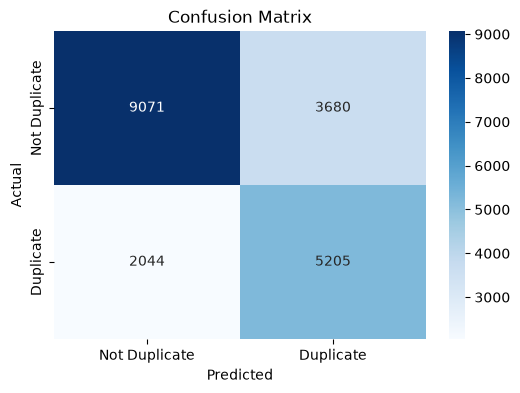

['../models/random_forest.pkl']

In [4]:
y_pred = rf.predict(X_test)
evaluate_classification(y_test, y_pred, labels=['Not Duplicate', 'Duplicate'])
joblib.dump(rf, '../models/random_forest.pkl')

## 4. Feature Importance

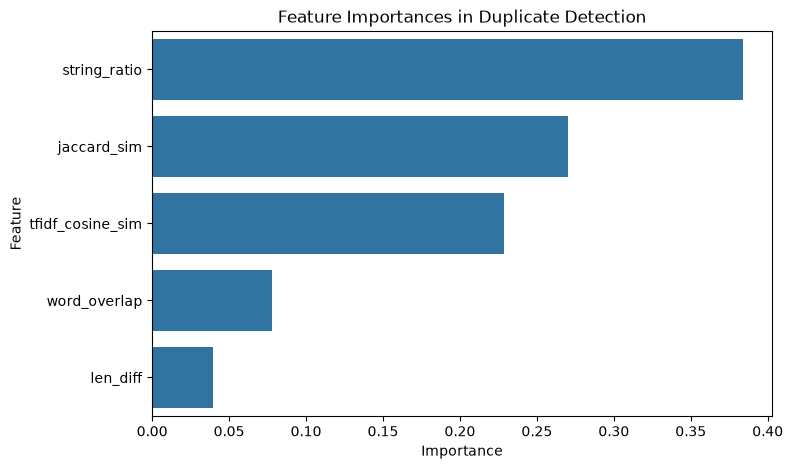

In [5]:
importances = rf.feature_importances_
feature_imp = pd.Series(importances, index=features).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=feature_imp, y=feature_imp.index)
plt.title('Feature Importances in Duplicate Detection')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

## Key Takeaways
- [x] In Classical NLP Pairwise tasks, **Feature Engineering** is king.
- [x] We successfully translated raw text into numerical similarity scores (Jaccard, Cosine, String Match).
- [x] A Random Forest easily digests these similarities to predict duplicate intents.